# Interactive simulation of test case study

First load packages and switch into the correct working directory

In [19]:
from pymob import Config

from lotka_volterra_case_study.sim import Simulation_v2

Load casestudy

In [20]:
config = Config("../scenarios/test_scenario_v2/settings.cfg")
config.case_study.package = "../.."

sim = Simulation_v2(config)
sim.setup()


MinMaxScaler(variable=rabbits, min=5.968110437683305, max=86.99133665713266)
MinMaxScaler(variable=wolves, min=7.203778019337644, max=62.829641338400535)
Results directory exists at '/home/flo-schu/projects/pymob/case_studies/lotka_volterra_case_study/results/test_scenario_v2'.
Scenario directory exists at '/home/flo-schu/projects/pymob/case_studies/lotka_volterra_case_study/scenarios/test_scenario_v2'.


/home/flo-schu/miniconda3/envs/lotka-volterra/lib/python3.11/site-packages/pymob/simulation.py:546: UserWarning: The number of ODE states was not specified in the config file [simulation] > 'n_ode_states = <n>'. Extracted the return arguments ['dprey_dt', 'dpredator_dt'] from the source code. Setting 'n_ode_states=2.
  warnings.warn(


In [21]:
# Prey birth rate (alpha * prey)
sim.config.model_parameters.alpha.min = 0.1
sim.config.model_parameters.alpha.max = 1.0
sim.config.model_parameters.alpha.free = True

# Predation rate (- beta * prey * predator)
sim.config.model_parameters.beta.min = 0.005
sim.config.model_parameters.beta.max = 0.05
sim.config.model_parameters.beta.free = True

# Predator reproduction rate (delta * prey * predator)
sim.config.model_parameters.delta.min = 0.005
sim.config.model_parameters.delta.max = 0.05
sim.config.model_parameters.delta.free = False

# Predator death rate (- gamma * predator)
sim.config.model_parameters.gamma.min = 0.1
sim.config.model_parameters.gamma.max = 1.0
sim.config.model_parameters.gamma.free = False


In [22]:
sim.config.model_parameters.delta.prior = "lognorm(s=0.01,scale=0.5)"
sim.config.model_parameters.gamma.prior = "lognorm(s=0.1,scale=0.5)"

## Run interactive simulation

In [23]:
sim.interactive()

Jax 64 bit mode: False
Absolute tolerance: 1e-07
         Trace Shapes:      
          Param Sites:      
         Sample Sites:      
alpha_normal_base dist     |
                 value     |
 beta_normal_base dist     |
                 value     |
      rabbits_obs dist 200 |
                 value 200 |
       wolves_obs dist 200 |
                 value 200 |


100%|██████████| 10000/10000 [00:26<00:00, 374.91it/s, init loss: 1969.1219, avg. loss [9501-10000]: 746.2985]
arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha  0.501  0.001    0.50    0.503        0.0      0.0    2066.0    1941.0   
beta   0.020  0.000    0.02    0.020        0.0      0.0    2075.0    1931.0   

       r_hat  
alpha    NaN  
beta     NaN  


<xarray.Dataset>
Dimensions:  (chain: 1, draw: 2000)
Coordinates:
  * chain    (chain) int64 0
  * draw     (draw) int64 0 1 2 3 4 5 6 7 ... 1993 1994 1995 1996 1997 1998 1999
Data variables:
    alpha    (chain, draw) float32 0.5021 0.5008 0.5016 ... 0.5019 0.5001 0.5004
    beta     (chain, draw) float32 0.01982 0.01984 0.01984 ... 0.01997 0.01988
Attributes:
    created_at:     2025-03-03T11:00:13.824963+00:00
    arviz_version:  0.20.0

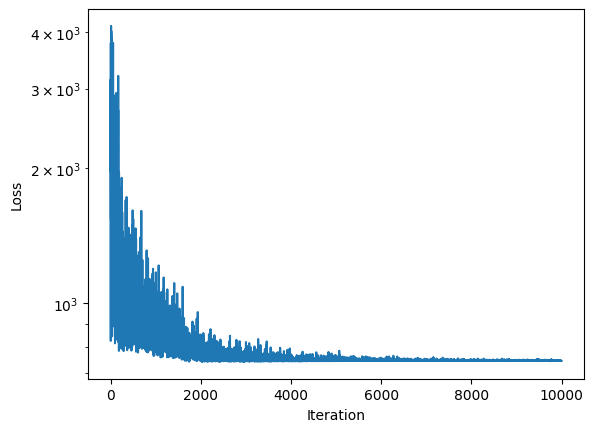

In [25]:
sim.config.jaxsolver.throw_exception = False
sim.dispatch_constructor()

sim.set_inferer("numpyro")
sim.inferer.config.inference_numpyro.kernel = "svi"
sim.inferer.config.inference_numpyro.svi_iterations = 10_000
sim.inferer.config.inference_numpyro.svi_learning_rate = 0.001
sim.inferer.run()

sim.inferer.idata.posterior